# **Extracting the Data**

In [1]:
import urllib.request
import os
import zipfile
import os

def download_data(force=False):
    """Download and extract course data from Zenodo."""

    zip_path = 'data.zip'
    data_dir = './data'

    if not os.path.exists(zip_path) or force:
        print("Downloading course data...")
        urllib.request.urlretrieve(
            'https://zenodo.org/records/18235955/files/data.zip?download=1',
            zip_path
        )
        print("Download complete")

    if not os.path.exists(data_dir) or force:
        print("Extracting data files...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(data_dir)
        print("Data extracted")

    return data_dir


if __name__ == "__main__":
    download_data()

Download complete
Extracting data files...
Data extracted


In [ ]:
import os

files = os.listdir('./data')
print(f"Datasets found: {files}")

Datasets found: ['ames_codebook.txt', 'use_of_force.txt', 'pretrial_data.csv', 'college_completion.csv', 'sharks.csv', 'electricity_data_validation.csv', 'cars_env.csv', 'pierce_county_house_sales.csv', 'diabetes-dataset.csv', 'brazil_default.csv', 'wages_hw.csv', 'divorce', 'drilling_rigs.csv', 'CardiacPatientData.csv', '2022 election cycle fundraising.csv', 'USA_cars_datasets.csv', 'cars_hw.csv', 'time_use.csv', 'mn_police_use_of_force.csv', 'airbnb_NYC.csv', 'patents.csv', 'SIPRI Military Expenditure Database.csv', 'mammogram.csv', 'VirginiaPretrialData2017Codebook.pdf', 'crimebystatecombinedwithunemployment.csv', 'Effectiveness of Bystander Cardiopulmonary Resuscitation and Survival Following Out-of-Hospital Cardiac Arrest.pdf', 'nhanes_meta_17_18.csv', 'heart_failure_clinical_records_dataset.csv', 'weapons-trade-register.csv', 'land_mines.csv', 'craiglist_cville_cars_long.csv', 'mammogram.txt', 'us_power_consumption.csv', 'cpr.txt', 'ames_prices.csv', 'metabric.csv', 'mnist', 'tec

# **Q1. Please answer the following questions in your own words.**

1. What makes a model "linear"? "Linear" in what?

What makes a model linear is when it has a linear pattern in its parameters or coefficient terms. This basically means that the coefficients are added up together in a straight line like way and aren't multiplied by each other or raised to any powers. The coefficients need to be linear in order for a variables in the model to be transformed like log(x) and squared in order to remain linear.

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

The coefficient on a dummy variable shows the difference in the predicted outcome relative to an omitted reference group. So, if there is an intercept in the model, a category must be left out in order to avoid multicollinearity. The dummy coefficient tells us how much lower/higher the category is compared to the baseline, holding other variables constant.

3. Can linear regression be used for classification? Explain why, or why not.

Linear regression can kind of be used for classification for predicting values and applying a cutoff, but it isn't great. The issue that arises is that linear regression can predict values below 0 and above 1, which doesn't make a whole lot of sense for probability. Logistic regression, which is a classification model is better because it is made for binary outcomes and can produce predicted probabilities in a proper range.

4. What are signs that your linear model is over-fitting?

A common sign that a model is overfitting is when the model performs well on training data but very bad on test data. Another sign that comes to mind is when the model becomes complex and starts capturing outliers instead of a real consistent pattern.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity is when one explanatory variable is highly correlated with another explanatory variable. This makes it quite hard to separate their individual effects. In the case of a two stage least squares regression, essentially, first regressing one predictor on to the others to see how much it is already explained by them. So, let's say that most of that variable is predicted by the others, than there is little unique variation. This basically means that the coefficient is unstable and hard to estimate in a precise manor.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable  and your features/control/response/independent variables  into your analysis?

You can include nonlinear relationships by adding transformed versions of variables. Some examples of these could be squared terms, cubic terms, or even logs. So if you had an x squared for example, it would have the effect of x on y to curve instead of staying constant. So the regression is still flexible but also able to be estimated with linear model methods.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient tells us the exchange change in the dependent variable or y from a +1 increase in the x or independent variable, all while holding all other variables constant. It essentially measures the marginal effect of a predictor on an outcome. The sign can tell us the driection and the size of the variable shows us the strength of the relationship.

8. Compare the train/test split and -fold cross validation.

A train/test split divides the data only once into a training and testing sets. It creates a simple and fast environment. The results depend on the split chosen. A k-fold validation on the other hand is more reliable because it keeps spliting the data into different validation and training groups and the averages the results. This is a more reliable model.

9. How is the  in -fold cross validation typically selected?

The value of k is chosen based on a reliability and computation time. So, 5 and 10 fold cross validation is the most commmon options because they give good tradeoffs. A larger k uses more data for training each time and can take longer, so a lower k can be faster.

# **Q2. Load ./data/Q1_clean.csv. The data include**

Price per night

Review Scores Rating: The average rating for the property

Neighbourhood: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by Neighbourhood; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by Neighbourhood.

The most expensive borough is Manhattan ($183.66), then Staten Island and Brooklyn. The cheapest one was the Bronx($75.28). The price distribution is right skewed which means that most listings are on the lower end of pricing with a few expensive liftings raising our average. The log reduces this though.

2. Regress price on Neighbourhood by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?

A dropped the Bronx and kept the intercept to avoid a dummy variable trap. The intercept is equal to the Bronx Average price which was $75.28 and each coefficient equals the difference between the borough's mean price and the Bronx mean. So take Manhattan for example at 108.23, it equals Manhattan's mean 183.66 minus the Bronx's mean 75.28.

3. Regress price on Review Scores Rating and a constant/intercept. Interpret the slope coefficient clearly in words.

The slope on Review Scores Rating is 1.02 which means that a 1 point increase in the review score is associated with a $1.02 higher nightly price on average. So you can infer that higher reviewed listings will have a slightly higher charge.

4. Regress price on both Neighbourhood and Review Scores Rating. How does the slope coefficient on Review Scores Rating change? How do the neighborhood averages change?

After adding borough controls, you see that the review score slope increases from 1.02 to 1.08. This means that borough differences was related to the relationship between ratings and price. The borough coefficients now represent price differences holding review scores constant.

5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for Review Scores Rating. Are the slopes similar across neighborhoods, or not?

This model gives each borough the ability to have its own rating slope. The Bronx has the basline slope set at 0.57, Queens has a smaller sloper at 0.50, and Brooklyn and Manhattan have larger slopes at around 1.3. This basically suggests that ratings matter more for pricing in Brooklyn and Manhattan than in the Bronxs and Queens. It's worth noting that Staten Island doesn't have a lot of observations so that could explain the negative slope.

6. Use cross validation to evaluate the models from parts 4, 5, and 6.

The borough review model has slightly lower RMSE with 145.14 compared to the interaction model at 145.98. This means that allowing different slopes doesn't really improve predictive performance to justify or explain the extra complexity. I'd say that based on this, the simpler model is better.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

sns.set_theme(style="whitegrid")

In [6]:
df = pd.read_csv("Q1_clean.csv")

df = df.rename(columns={
    "Review Scores Rating":"Review_Scores_Rating",
    "Neighbourhood ":"Neighbourhood"
})

df = df[["Price","Review_Scores_Rating","Neighbourhood"]]

df = df.dropna()

print(df.head())

   Price  Review_Scores_Rating Neighbourhood
0    549                  96.0     Manhattan
1    149                 100.0      Brooklyn
2    250                 100.0     Manhattan
3     90                  94.0      Brooklyn
4    270                  90.0     Manhattan


In [7]:
group_means = df.groupby("Neighbourhood")[["Price","Review_Scores_Rating"]].mean()

print(group_means.sort_values("Price",ascending=False))

                    Price  Review_Scores_Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378


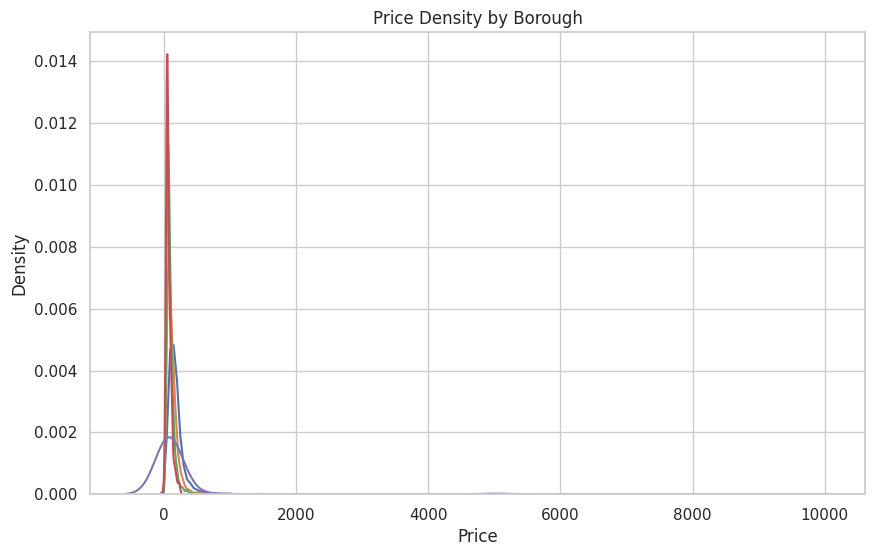

In [8]:
plt.figure(figsize=(10,6))

for n in df["Neighbourhood"].unique():
    sns.kdeplot(df[df["Neighbourhood"]==n]["Price"],label=n)

plt.title("Price Density by Borough")

plt.show()

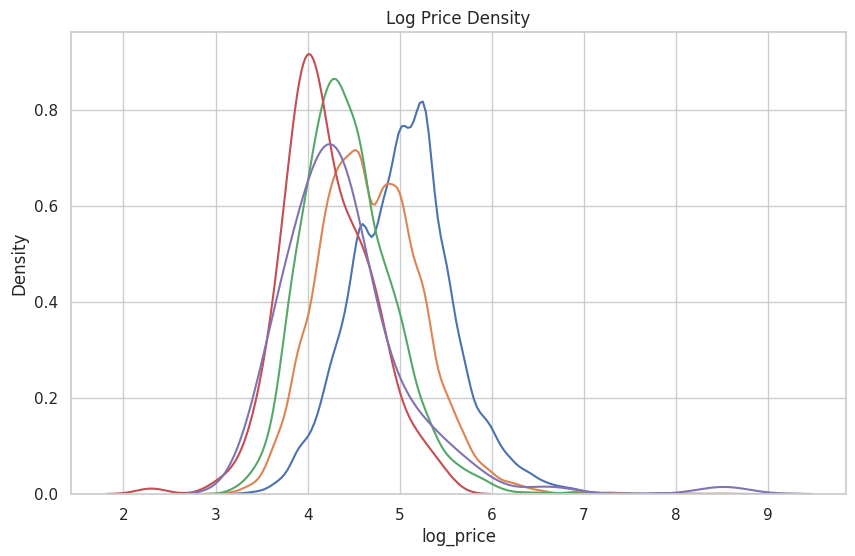

In [9]:
df["log_price"]=np.log(df["Price"])

plt.figure(figsize=(10,6))

for n in df["Neighbourhood"].unique():
    sns.kdeplot(df[df["Neighbourhood"]==n]["log_price"],label=n)

plt.title("Log Price Density")

plt.show()

In [10]:
X = pd.get_dummies(df["Neighbourhood"],drop_first=True,dtype=float)

X = sm.add_constant(X)

model = sm.OLS(df["Price"],X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        17:34:00   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [11]:
X = sm.add_constant(df["Review_Scores_Rating"])

model_review = sm.OLS(df["Price"],X).fit()

print(model_review.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        17:36:25   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   60.8784 

In [12]:
print(model_review.params)

const                   60.878391
Review_Scores_Rating     1.020827
dtype: float64


In [13]:
X = pd.get_dummies(df["Neighbourhood"],drop_first=True,dtype=float)

X["Review_Scores_Rating"]=df["Review_Scores_Rating"]

X = sm.add_constant(X)

model2 = sm.OLS(df["Price"],X).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Fri, 13 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        17:37:46   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                  -23.8126 

In [14]:
dummies = pd.get_dummies(df["Neighbourhood"],drop_first=True,dtype=float)

X = pd.DataFrame()

X["Review_Scores_Rating"]=df["Review_Scores_Rating"]

for col in dummies.columns:
    X[col]=dummies[col]

for col in dummies.columns:
    X[col+"_interaction"]=(
        dummies[col]*df["Review_Scores_Rating"]
    )

X = sm.add_constant(X)

model3 = sm.OLS(df["Price"],X).fit()

print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:39:08   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [15]:
XA = pd.get_dummies(df["Neighbourhood"],drop_first=True,dtype=float)

XA["Review_Scores_Rating"]=df["Review_Scores_Rating"]

XB = XA.copy()

for col in pd.get_dummies(df["Neighbourhood"],
                          drop_first=True,
                          dtype=float).columns:

    XB[col+"_interaction"]=(
        pd.get_dummies(df["Neighbourhood"],
                       drop_first=True,
                       dtype=float)[col]
        * df["Review_Scores_Rating"]
    )

y = df["Price"]

kf = KFold(n_splits=10,shuffle=True,random_state=1)

lr = LinearRegression()

rmse_A = np.sqrt(
    -cross_val_score(lr,XA,y,
                     cv=kf,
                     scoring="neg_mean_squared_error").mean()
)

rmse_B = np.sqrt(
    -cross_val_score(lr,XB,y,
                     cv=kf,
                     scoring="neg_mean_squared_error").mean()
)

print(rmse_A)
print(rmse_B)

145.13993148609902
145.9766207697284


# **Q3. This question is a case study for linear models. The data are about car prices. In particular, they include:**

Price: In Indian rupees
Seating_Capacity: Number of seats
Body_Type: crossover, hatchback, muv, sedan, suv
Make_Year: The year the car was made

1. Load cars_hw.csv. Summarize the Price variable and create a kernel density plot. Use .groupby() and .describe() to summarize prices by Body_Type. Make a grouped kernel density plot by Body_Type. Which car types are the most expensive? Which have the most variance?

Summary stats given by describe gives us an idea of the right skewedness of the distribution as high price vehicles are causing it. We know this because of the difference between the mean and the maximum. The kernal density plot shows that the car prices are right skewed, which basically means that most cars are lower priced with a few being expensive.
Based on the price distribution by body type graph, SUVS have the highest price on average. Crossovers have a somewhat medium price on average. Hatchbacks on the otherhand have the lowest average prices and the smallest spread. SUVs seem to also have the greatest variation in price.

2. Regress Price on Seating_Capacity. What's the slope coefficient? Interpret it. Now treat Seating_Capacity as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?

The slope coefficient is 59267.998, meaning that each additional seat is associated with a 59267.998 rupees higher price on average. This essentially suggest that larger vehicles will be more expensive. As for when we treat seating capacity as categorical, we see price differences between seat categories. The 6 seat vehicles have the largest positive and statistically significant price differences, while 7 seat is also more expensive. Since prices do not increase smoothly across all categories thought, this shows the relationship between seating and pricing is perfectly linear.

3. Use Make_Year to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of Age to include in a regression of Price on Age.

Using 10 fold cross validation, the otipmal number of powers of Age to include in a regression of Price on Age was 5. 5 produced the lowest RMSE and suggest that the relationship between age and price is nonlinear. This basically means that depreciation does not happen at a constant rate and instead the price falls faster earlier on rather than later on when the car gets old.

4. Plot Price against Age, and then model-predicted price against Age. Does the model accurately fit the patterns in the data?

The scatter plot shows that vehicle price generally decreases as age increases. The predicted price curve follows the negative downward pattern and suggest that the model captures the general trend. But, there is some variation around the predicted values which means that factors desides age also affect price.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")

In [ ]:
df = pd.read_csv("./data/cars_hw.csv")

print(df.head())
print(df.shape)
print(df.columns)

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
(976, 12)
Index(['Unnamed: 0', '

In [ ]:
print(df["Price"].describe())

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


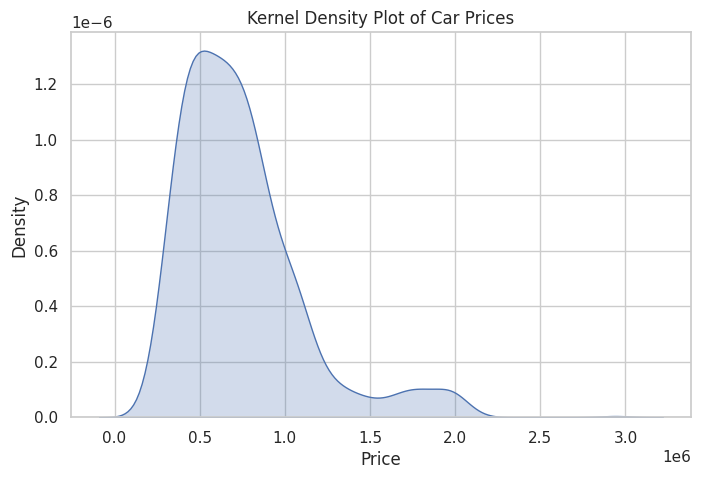

In [ ]:
plt.figure(figsize=(8,5))
sns.kdeplot(df["Price"], fill=True)

plt.title("Kernel Density Plot of Car Prices")
plt.xlabel("Price")
plt.show()

In [ ]:
group_summary = df.groupby("Body_Type")["Price"].describe()

print(group_summary)

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


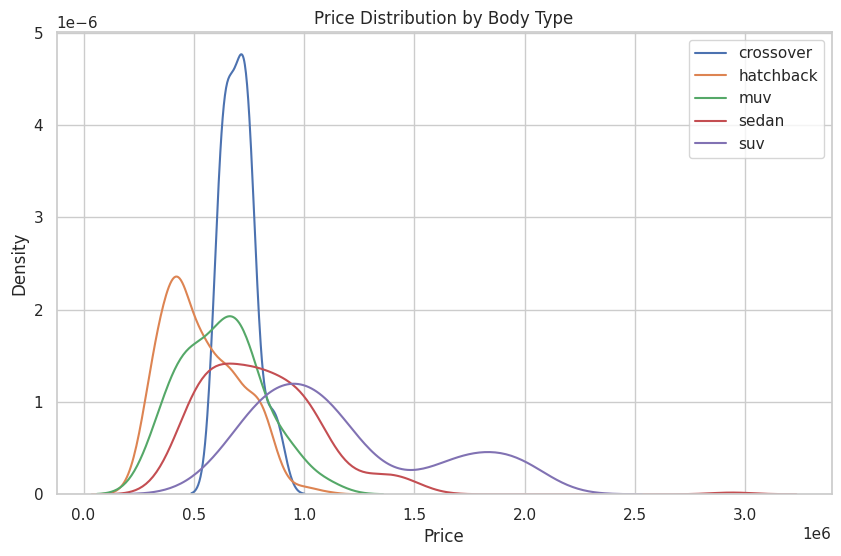

In [ ]:
plt.figure(figsize=(10,6))

for b in sorted(df["Body_Type"].unique()):
    sns.kdeplot(df[df["Body_Type"]==b]["Price"], label=b)

plt.legend()
plt.title("Price Distribution by Body Type")
plt.xlabel("Price")
plt.show()

In [ ]:
X = sm.add_constant(df["Seating_Capacity"])
model = sm.OLS(df["Price"], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Thu, 12 Mar 2026   Prob (F-statistic):             0.0245
Time:                        19:49:25   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

In [ ]:
print("Slope:", model.params["Seating_Capacity"])

Slope: 59267.99803672166


In [ ]:
df["Seating_Capacity"] = pd.to_numeric(df["Seating_Capacity"], errors="coerce")
df = df.dropna(subset=["Seating_Capacity","Price"])
df["Seating_Capacity"] = df["Seating_Capacity"].astype(int)
seat_dummies = pd.get_dummies(df["Seating_Capacity"], drop_first=True)
seat_dummies = seat_dummies.astype(float)
X2 = sm.add_constant(seat_dummies)
model2 = sm.OLS(df["Price"], X2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Thu, 12 Mar 2026   Prob (F-statistic):           0.000267
Time:                        19:51:55   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        1.88e+05   3.64e+05      0.516      0.6

In [ ]:
current_year = df["Make_Year"].max()

df["Age"] = current_year - df["Make_Year"]

print(df[["Make_Year","Age"]].head())

   Make_Year  Age
0       2017    5
1       2016    6
2       2019    3
3       2017    5
4       2017    5


In [ ]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)

degrees = range(1,6)

rmse_results = []

for d in degrees:

    X = pd.DataFrame()

    for i in range(1,d+1):
        X[f"Age^{i}"] = df["Age"]**i

    y = df["Price"]

    rmse_fold = []

    for train_index, test_index in kf.split(X):

        X_train = X.iloc[train_index]
        X_test = X.iloc[test_index]

        y_train = y.iloc[train_index]
        y_test = y.iloc[test_index]

        model = LinearRegression()
        model.fit(X_train,y_train)

        pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test,pred))

        rmse_fold.append(rmse)

    rmse_results.append(np.mean(rmse_fold))

print(list(zip(degrees,rmse_results)))

[(1, np.float64(310378.3968869913)), (2, np.float64(310457.7875681931)), (3, np.float64(309616.73813036096)), (4, np.float64(308930.14521646907)), (5, np.float64(307509.78748945135))]


In [ ]:
best_degree = degrees[np.argmin(rmse_results)]

print("Best polynomial degree:",best_degree)

Best polynomial degree: 5


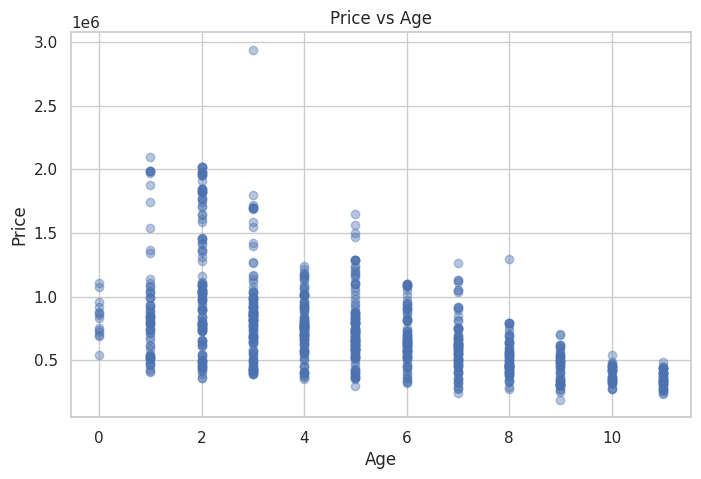

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"],df["Price"],alpha=.4)

plt.xlabel("Age")
plt.ylabel("Price")

plt.title("Price vs Age")

plt.show()

In [ ]:
X = pd.DataFrame()

for i in range(1,best_degree+1):
    X[f"Age^{i}"] = df["Age"]**i

model_final = LinearRegression()

model_final.fit(X,df["Price"])

df["Predicted_Price"] = model_final.predict(X)

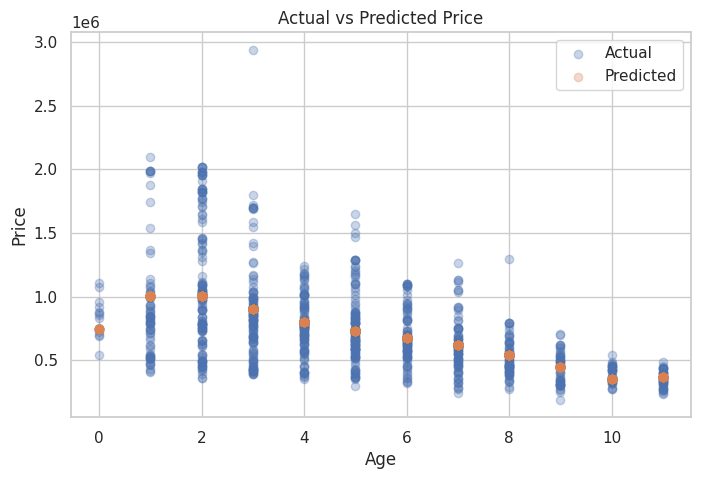

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"],df["Price"],alpha=.3,label="Actual")

plt.scatter(df["Age"],df["Predicted_Price"],alpha=.3,label="Predicted")

plt.legend()

plt.xlabel("Age")

plt.ylabel("Price")

plt.title("Actual vs Predicted Price")

plt.show()

# **Q4. This question refers to the heart_hw.csv data. It contains three variables:**

y: Whether the individual survived for three years, coded 0 for death and 1 for survival

age: Patient's age

transplant: labelled control for not receiving a transplant and labelled
treatment for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?

The survival rate in the control group is 0.1176 and the survival rate in the treatment group is 0.3478. The average treatment effect is 0.2302, which means that the transplant patients have a 23% higher probability of surviving three years compared to the controlled patients.

2. Regress y on transplant using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.

The intercept is 0.1176, which equals the survival rate for the control group. The transplant coefficient is 0.2302 which equals the difference between the treatment and control survival rates. So it basically produces the same result as question 1.


3. Regress y on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?

When you control for age, the transplant coefficient becomes 0.2647 which is larger than the other ATE at 0.2302. This means that age is masking the treatment effect in the simple comparison. The age coefficient is -0.0136 which means that survival probability decreases as age increases. Also, the intercept is 0.7020 which means that the predicted survival probability for a control patient as age 0 is not meaningful on its own. So comparing it to the ATE, the regression shows that the transplant effect is stronger once age differences are taken into account.


4. Now, include transplant, age, and transplant * age as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?

The transplant coefficient is 0.9078 and the interaction coefficient is -0.0146. This basically means that the transplant effect depends on age and appears to get smaller as age increase. The treatment effect on the other hand, is not constant across all patients. Younger or more youthful patients will have more benefit from the transplant thant older ones.

5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.

0.4371 is the transplant only model, 0.4210 is the transplant and age model, 0.4201 for the interaction model. The interaction model is best but for a small margin over transplant and age. That means that adding age improves the prediction and interaction gives a slight additional improvement.


6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?

I think that if this model were used to prioritize transplant access, there might be some ethical concerns. One, using this model could decrease fairness if it replaces the judgement of doctors instead of actually supporting. Two, the model uses too few variables and leaves out important outside factors. Lastly, the model will disadvantage older patients because of their low survival predictions. The model should be used as only one part of the decision making process in my opinion.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

sns.set_theme(style="whitegrid")

In [17]:
df = pd.read_csv("heart_hw.csv")

print(df.head())
print(df.shape)
print(df.columns.tolist())

   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0
(103, 4)
['Unnamed: 0', 'age', 'transplant', 'y']


In [18]:
control_mean = df[df["transplant"] == "control"]["y"].mean()
treatment_mean = df[df["transplant"] == "treatment"]["y"].mean()
ATE = treatment_mean - control_mean

print("Control survival rate:", control_mean)
print("Treatment survival rate:", treatment_mean)
print("ATE:", ATE)

Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE: 0.23017902813299232


In [19]:
df["transplant_dummy"] = (df["transplant"] == "treatment").astype(int)

X1 = sm.add_constant(df[["transplant_dummy"]])
model1 = sm.OLS(df["y"], X1).fit()

print(model1.summary())
print(model1.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Fri, 13 Mar 2026   Prob (F-statistic):             0.0133
Time:                        17:48:39   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.1176      0.075  

In [20]:
X2 = sm.add_constant(df[["transplant_dummy", "age"]])
model2 = sm.OLS(df["y"], X2).fit()

print(model2.summary())
print(model2.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           0.000357
Time:                        17:48:51   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.7020      0.196  

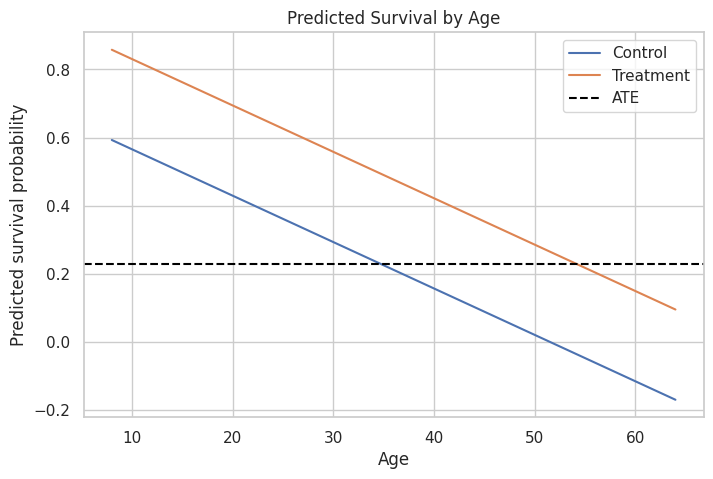

In [21]:
ages = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model2.params["const"] + model2.params["age"] * ages
pred_treatment = (
    model2.params["const"]
    + model2.params["transplant_dummy"]
    + model2.params["age"] * ages
)

plt.figure(figsize=(8,5))
plt.plot(ages, pred_control, label="Control")
plt.plot(ages, pred_treatment, label="Treatment")
plt.axhline(ATE, linestyle="--", color="black", label="ATE")
plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Predicted Survival by Age")
plt.legend()
plt.show()

In [22]:
df["interaction"] = df["transplant_dummy"] * df["age"]

X3 = sm.add_constant(df[["transplant_dummy", "age", "interaction"]])
model3 = sm.OLS(df["y"], X3).fit()

print(model3.summary())
print(model3.params)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Fri, 13 Mar 2026   Prob (F-statistic):           0.000310
Time:                        17:51:06   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.3549      0.280  

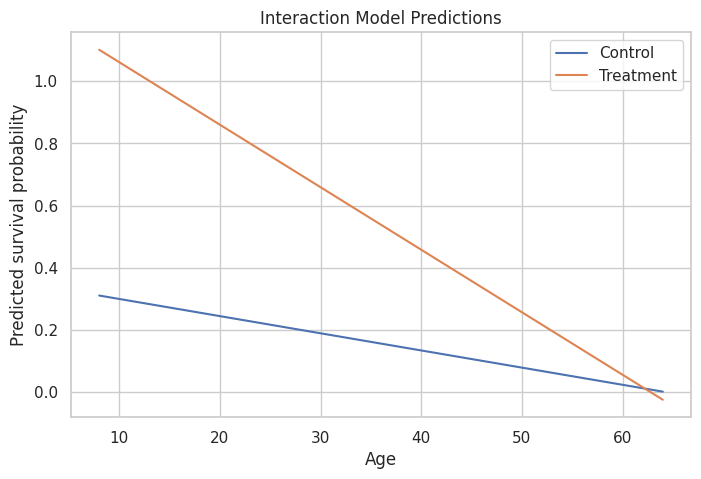

In [23]:
pred_control_int = model3.params["const"] + model3.params["age"] * ages
pred_treatment_int = (
    model3.params["const"]
    + model3.params["transplant_dummy"]
    + (model3.params["age"] + model3.params["interaction"]) * ages
)

plt.figure(figsize=(8,5))
plt.plot(ages, pred_control_int, label="Control")
plt.plot(ages, pred_treatment_int, label="Treatment")
plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Interaction Model Predictions")
plt.legend()
plt.show()

In [24]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)

models = [
    df[["transplant_dummy"]],
    df[["transplant_dummy", "age"]],
    df[["transplant_dummy", "age", "interaction"]]
]

names = ["Transplant only", "Transplant + Age", "Interaction"]
y = df["y"]

for X, name in zip(models, names):
    rmse_list = []

    for train, test in kf.split(X):
        X_train = X.iloc[train]
        X_test = X.iloc[test]
        y_train = y.iloc[train]
        y_test = y.iloc[test]

        lr = LinearRegression()
        lr.fit(X_train, y_train)
        pred = lr.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, pred))
        rmse_list.append(rmse)

    print(name, np.mean(rmse_list))

Transplant only 0.4371241492420901
Transplant + Age 0.4209998366059898
Interaction 0.4201082469734157
